
# 📊 Segmentação de Clientes com K-Means  
**Projeto de Ciência de Dados – Portfólio**

## 📌 Contexto
Este projeto utiliza o dataset *Mall Customers* para realizar a **segmentação de clientes** com base em comportamento de consumo e renda anual.

A ideia central é identificar grupos de clientes com características semelhantes para apoiar **decisões estratégicas de marketing**, como campanhas personalizadas, retenção e priorização de clientes.

---

## 🎯 Objetivo do Projeto
Aplicar o algoritmo **K-Means Clustering** para:
- Identificar padrões de comportamento entre clientes
- Criar segmentos interpretáveis
- Traduzir os clusters em **insights de negócio**



## 🧰 Tecnologias Utilizadas
- Python
- Pandas / NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook

---


In [1]:

# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score



## 📥 Carregamento dos Dados


In [9]:

df = pd.read_csv(r"Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



## 🔎 Análise Exploratória dos Dados (EDA)

Nesta etapa analisamos:
- Estrutura do dataset
- Tipos de variáveis
- Estatísticas descritivas
- Distribuição das variáveis numéricas


In [10]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [11]:

df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


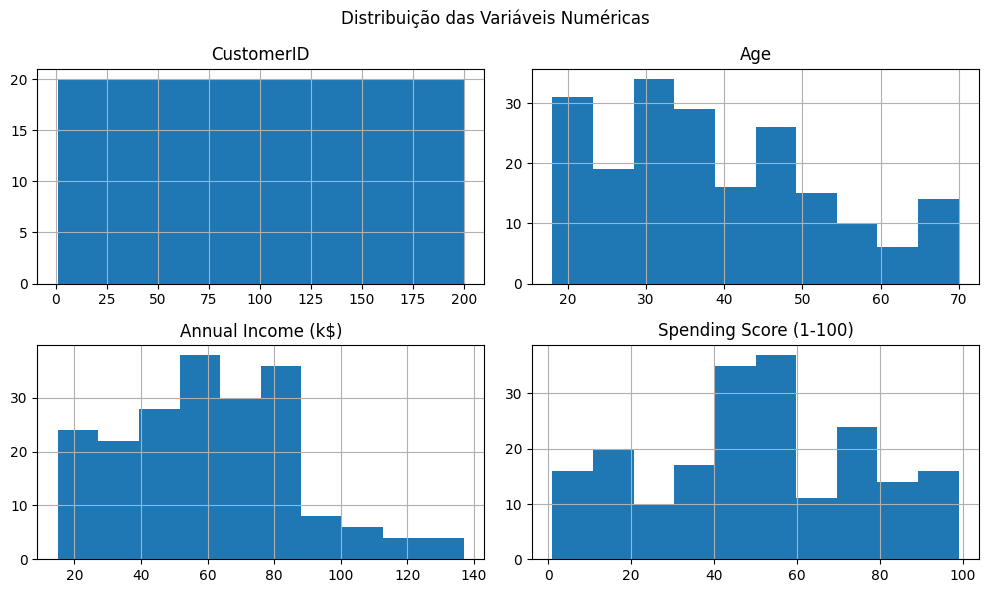

In [12]:

# Histogramas das variáveis numéricas
df.hist(figsize=(10,6))
plt.suptitle("Distribuição das Variáveis Numéricas")
plt.tight_layout()
plt.show()



## ⚙️ Pré-processamento

O algoritmo K-Means é sensível à escala das variáveis.
Por isso, utilizamos **padronização (StandardScaler)** antes da modelagem.


In [13]:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## 🔢 Definição do Número Ideal de Clusters

Utilizamos duas abordagens:
- **Elbow Method**: analisa a redução da inércia
- **Silhouette Score**: mede a qualidade da separação entre clusters


In [14]:

inertias = []
silhouette_scores = []

K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))


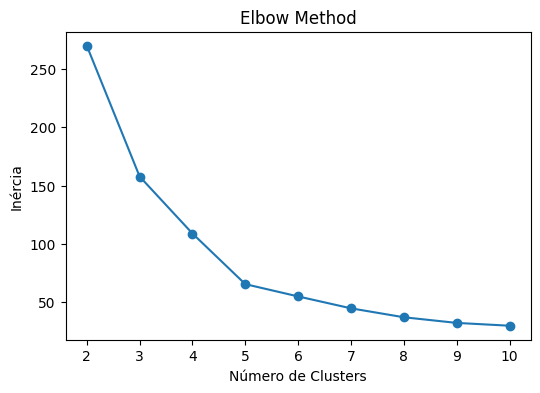

In [15]:

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inércia")
plt.title("Elbow Method")
plt.show()


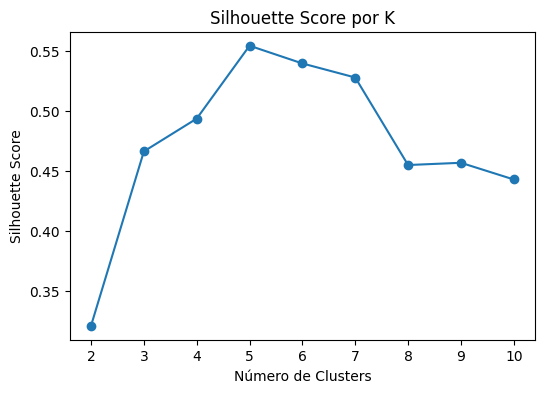

In [16]:

plt.figure(figsize=(6,4))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por K")
plt.show()



Com base no **Silhouette Score**, escolhemos **k = 5 clusters**.


In [17]:

kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
df['Cluster'] = kmeans.fit_predict(X_scaled)



## 📊 Visualização dos Clusters


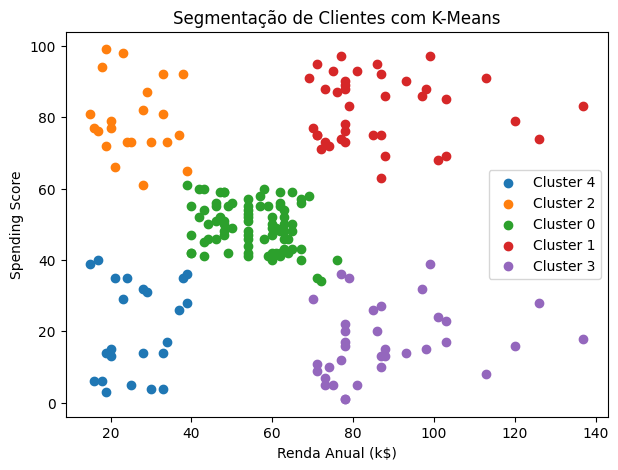

In [18]:

plt.figure(figsize=(7,5))
for cluster in df['Cluster'].unique():
    subset = df[df['Cluster'] == cluster]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'], label=f'Cluster {cluster}')

plt.xlabel("Renda Anual (k$)")
plt.ylabel("Spending Score")
plt.title("Segmentação de Clientes com K-Means")
plt.legend()
plt.show()



## 🧠 Interpretação dos Clusters (Linguagem de Negócio)

- **Cluster 0 – Clientes Médios**
  - Renda e gasto moderados
  - Representam a maior parte da base

- **Cluster 1 – Clientes Premium**
  - Alta renda e alto gasto
  - Alto valor para o negócio

- **Cluster 2 – Jovens Engajados**
  - Baixa renda, mas alto gasto
  - Potencial de fidelização

- **Cluster 3 – Alto Potencial**
  - Alta renda, mas baixo gasto
  - Oportunidade de conversão

- **Cluster 4 – Baixo Valor Atual**
  - Baixa renda e baixo gasto
  - Menor prioridade estratégica



## ✅ Conclusões

- O K-Means permitiu identificar **5 perfis distintos de clientes**
- A segmentação pode ser usada para:
  - Marketing direcionado
  - Programas de fidelidade
  - Otimização de campanhas

---

## 🚀 Próximos Passos
- Testar outros algoritmos de clustering (DBSCAN, Hierárquico)
- Utilizar PCA para visualização
- Criar um dashboard interativo (Streamlit / Power BI)
- Avaliar impacto financeiro por cluster
